<a href="https://colab.research.google.com/github/raulfilipeKA/POO/blob/POO/TMC_praticaStudy4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

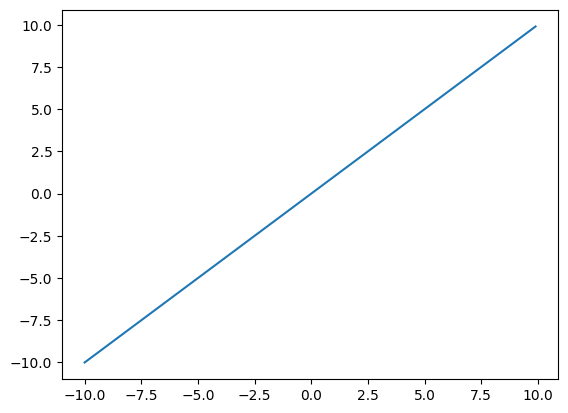

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# definir a função de ativação linear

def linear(z):
  return z

# visualizacao do grafico da linear
xx = np.arange(-10,10,.1)
yy = linear(xx)
plt.plot(xx,yy)

valor da sigmoid em 10 = 0.9999546021312976
valor da sigmoid em -10 = 4.5397868702434395e-05
valor da sigmoid em 0 = 0.5


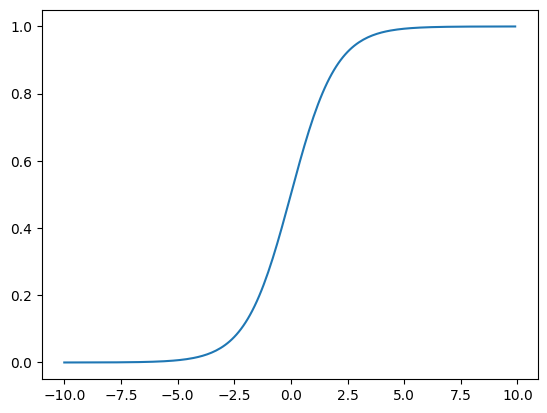

In [2]:
# definir a função de ativação sigmoid

def sigmoid(z):
  return 1/(1+np.exp(-z))

# visualizacao do grafico da sigmoide
xx = np.arange(-10,10,.1)
yy = sigmoid(xx)
plt.plot(xx,yy)

#
z=10
print(f"valor da sigmoid em {z} = {sigmoid(z)}")
z=-10
print(f"valor da sigmoid em {z} = {sigmoid(z)}")
z=0
print(f"valor da sigmoid em {z} = {sigmoid(z)}")

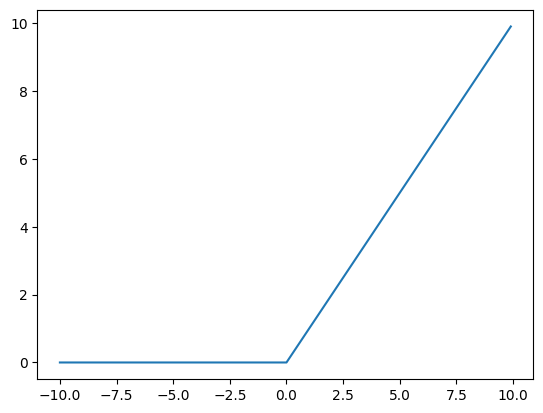

In [3]:
# definição da ativação relu
def relu(z):
  return z * (z > 0)

# visualizacao do grafico da relu
xx = np.arange(-10,10,.1)
yy = relu(xx)
plt.plot(xx,yy)

In [4]:
# camada densa como função np, com activação sigmoide

activation = sigmoid

def dense(x,W,b):
  z = np.matmul(x,W)+b
  y = activation(z)
  return y

In [5]:
# Batch (lote) de inputs
x = np.array([[1.,0.],[0.,1.],[.5,.5]])
# Geração de matriz de pesos aleatória
input_size = x.shape[1]
num_Neurons = 3
W = np.random.normal(0,1 , size=(input_size,num_Neurons))
# vetor de bias
b = np.ones((1,num_Neurons))
print("Pesos:")
print(W)
print("bias:")
print(b)
# aplicação da rede densa
y = dense(x,W,b)
print("outputs:")
print(y)

Pesos:
[[ 0.85097987 -1.30307343 -0.2866405 ]
 [ 0.7014031   0.21042289 -0.26766575]]
bias:
[[1. 1. 1.]]
outputs:
[[0.86424211 0.42480633 0.67114306]
 [0.8457179  0.77037377 0.6753173 ]
 [0.85522595 0.61151258 0.67323361]]


In [6]:
# camada densa como função np, com activação relu
activation = relu

def dense(x,W,b):
  y = np.matmul(x,W)+b
  y = activation(y)
  return y

In [7]:
# Batch (lote) de inputs
x = np.array([[1.,0.],[0.,1.],[.5,.5]])
# Geração de matriz de pesos aleatória
input_size = x.shape[1]
num_Neurons = 3
W = np.random.normal(0,1 , size=(input_size,num_Neurons))
# vetor de bias
b = np.ones((1,num_Neurons))
print("Pesos:")
print(W)
print("bias:")
print(b)
# aplicação da rede densa
y = dense(x,W,b)
print("outputs:")
print(y)

Pesos:
[[ 0.83575907  1.28550006  0.34317566]
 [ 0.44868171  0.43376618 -1.04520725]]
bias:
[[1. 1. 1.]]
outputs:
[[ 1.83575907  2.28550006  1.34317566]
 [ 1.44868171  1.43376618 -0.        ]
 [ 1.64222039  1.85963312  0.64898421]]


### Camadas/Layers densas como classes

In [8]:
import numpy as np

class layer_dense:
  def __init__(self,input_size,output_size,activation):

    W_size = (input_size,output_size)
    self.W = np.random.normal(0,1,size=W_size)  # inicialização standard dos pesos

    b_size = (1,output_size)
    self.b = np.zeros(b_size)  # inicialização standard dos bias

    self.activation = activation

  def __call__(self,inputs):
    return self.activation(np.matmul(inputs,self.W)+self.b)  # operação da rede

In [9]:
# Gerar objeto camada densa
layer = layer_dense(2,3,relu)
#
print(layer.W)
print(layer.b)

[[-0.25987286 -0.20955249  0.66054001]
 [-0.01672632 -0.79966051  0.97876759]]
[[0. 0. 0.]]


In [10]:
x = np.array([[1.,0.],[0.,1.],[.5,.5]])
print(x.shape)
layer(x)

(3, 2)


array([[-0.        , -0.        ,  0.66054001],
       [-0.        , -0.        ,  0.97876759],
       [-0.        , -0.        ,  0.8196538 ]])

In [11]:
# Alter pesos e bias
layer.W = np.ones((2,3))
layer.b = np.ones((1,3))
# nova avaliação dos inputs
layer(x)

array([[2., 2., 2.],
       [2., 2., 2.],
       [2., 2., 2.]])

### Rede Neuronal densa

In [12]:
class neuralNet:
  def __init__(self,layers):

    self.layers = layers

  def __call__(self,inputs):
    y = inputs
    outputs = [y]
    for layers in self.layers:
      y=layers(y)
      outputs += [y]
    return y, outputs

  def weights(self):
    weights = []
    for layers in self.layers:
      weights += [layers.W,layers.b]
    return weights

In [13]:
# gerar modelo de rede neuronal com camadas densas
#
model = neuralNet([layer_dense(2,3,relu),layer_dense(3,4,linear)])
#
# Batch (lote) de inputs
#x = np.array([[1.,0.],[0.,1.],[.5,.5]])
x = np.array([[1.,1.]])
# outputs do modelo
print("outputs:")
y,_ = model(x)
print(y)
# Parametros
print("Parametros:")
print(model.weights())

outputs:
[[-0.09900978 -1.48837398  1.91597749 -1.90777428]]
Parametros:
[array([[ 0.22042804,  0.50323202,  0.75926573],
       [ 1.64722947,  0.37802899, -0.2580675 ]]), array([[0., 0., 0.]]), array([[ 0.21326751, -0.14566185,  0.53424188, -1.53322315],
       [-0.27825595, -0.33056901,  0.57808321,  1.2358257 ],
       [-0.50300324, -1.84559701,  0.81555443, -0.2660096 ]]), array([[0., 0., 0., 0.]])]


In [14]:
# Atualização de parametros dum modelo de rede
#
for layer in model.layers:
  layer.W = np.ones(layer.W.shape)
  layer.b = 2*np.ones(layer.b.shape)

# outputs do modelo
print("outputs:")
y,_ = model(x)
print(y)
# Parametros
print("Parametros:")
print(model.weights())



outputs:
[[14. 14. 14. 14.]]
Parametros:
[array([[1., 1., 1.],
       [1., 1., 1.]]), array([[2., 2., 2.]]), array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]]), array([[2., 2., 2., 2.]])]


## Aula 3 Descida Gradiente

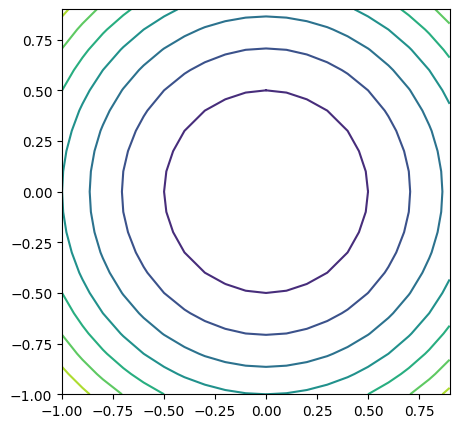

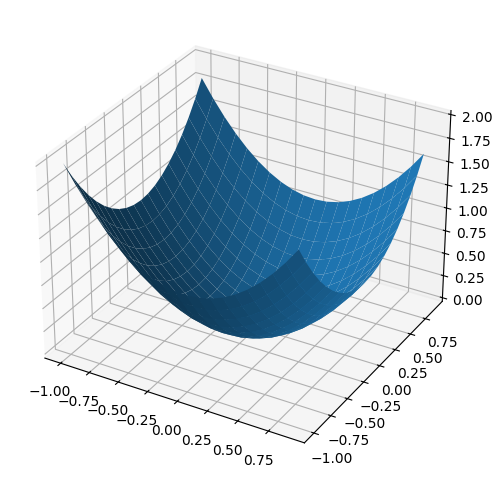

In [15]:
import numpy as np
import matplotlib.pyplot as plt

#
# Função objetivo
def fun(x,y,a=1):
  z=a*x**2+y**2
  return z

# janela de visualizacao
x=np.arange(-1,1,.1)
y=x
#
# curvas de nivel
plt.figure(figsize=(5, 5))
X,Y=np.meshgrid(x,y)
Z=fun(X,Y)
plt.contour(X,Y,Z)
#
# grafico
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X, Y, Z)

In [16]:
# gradiente de f

def gradf(x,y,a=1):
  dxf=2*a*x
  dyf=2*y
  grad=np.array((dxf,dyf))
  return grad

# exemplo
gradf(2,1)

array([4, 2])

solução aproximada= [0.10737418 0.10737418]
gradiente na solução aproximada= [0.21474836 0.21474836]
valor da função na solução= 0.023058430092136952


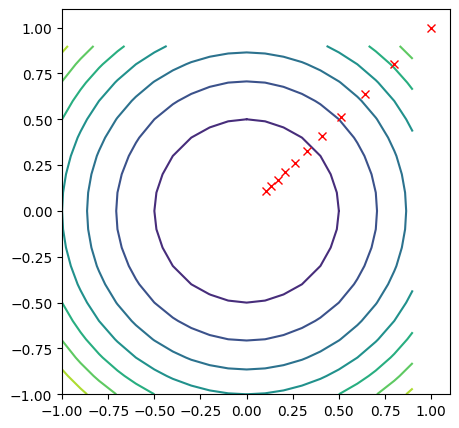

In [17]:
# learning rate
lr=.1  # experimentar tambem 1, 1.01, 0.99, 0.5 (com N=1)
# numero de iteracoes
N=10
# semente
X=np.array([1,1])
#
lista=np.zeros((N+1,2))
lista[0,:]=X
#
a=1    # experimentar a=5, 7, 20

for i in range(N):
  X=X-lr*gradf(X[0],X[1],a)
  lista[i+1]=X

print("solução aproximada=",X)
print("gradiente na solução aproximada=",gradf(X[0],X[1],a))
print("valor da função na solução=",fun(X[0],X[1],a))
#print("lista de iterações:",lista)

# visualizacao grafica
plt.figure(figsize=(5, 5))
x=np.arange(-1,1,.1)
y=x
X,Y=np.meshgrid(x,y)
Z=fun(X,Y,a)
plt.contour(X,Y,Z)
plt.plot(lista[:,0],lista[:,1],'rx')

### Um exemplo com minimos locais

In [18]:
def fun(x,y):
     z=x**4-12*x**2-4*x+y**4-16*y**2-5*y-20*np.cos(x-2.5)*np.cos(y-2.9)
     return z

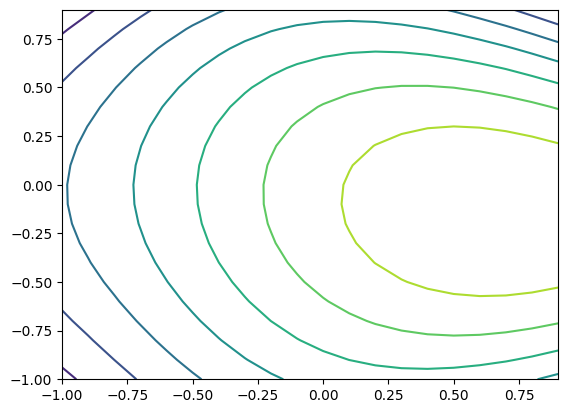

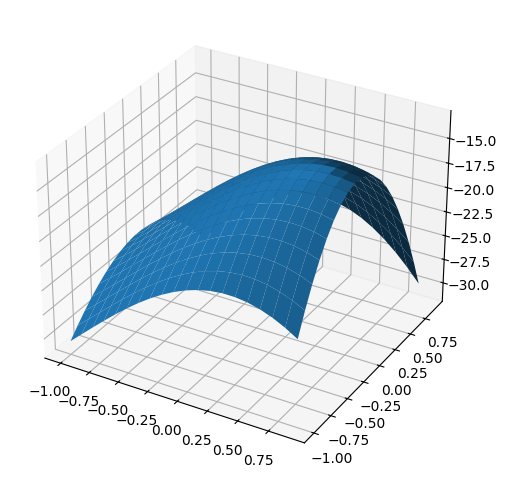

In [19]:
# Janela de visualização/procura
x_min = -1
x_max = 1
x=np.arange(x_min,x_max,.1)
y_min = x_min
y_max = x_max
y=np.arange(y_min,y_max,.1)
X,Y=np.meshgrid(x,y)
#
Z=fun(X,Y)
plt.contour(X,Y,Z)#, [levels], **kwargs)
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X, Y, Z)

solução aproximada= [-7.17517198e+00  2.38045050e+28]
gardiente final= [0. 0.]


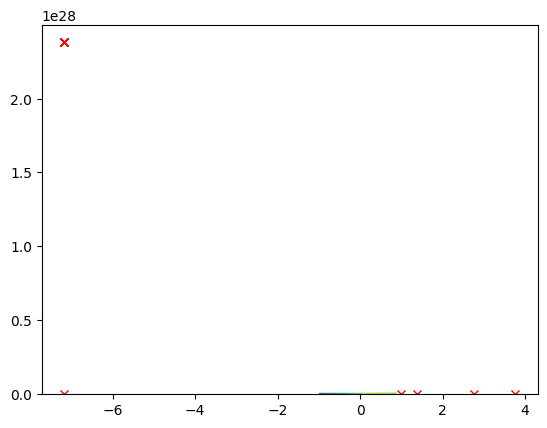

In [20]:
lr=0.1 # taxa de aprendizagem
N=10 # num de iterações

# semente escolhida a olho
X=np.array([1,1])

# semente escolhida aleatoriamente
#x0=np.random.uniform(x_min,x_max)
#y0=np.random.uniform(y_min,y_max)
#X=np.array([x0,y0])

lista=np.zeros((N+1,2))
lista[0,:]=X

h=1e-3 # para diferenças finitas

for i in range(N):
  dxf=(fun(X[0]+h,X[1])-fun(X[0]-h,X[1]))/(2*h) # diferenças finitas para o cálculo (aprox) de dfdx
  dyf=(fun(X[0],X[1]+h)-fun(X[0],X[1]-h))/(2*h) # diferenças finitas para o cálculo (aprox) de dfdx
  gradf=np.array([dxf,dyf])
  X=X-lr*gradf
  lista[i+1]=X

print("solução aproximada=",X)
print("gardiente final=",gradf)

x=np.arange(x_min,x_max,.1)
y=np.arange(y_min,y_max,.1)
X,Y=np.meshgrid(x,y)
Z=fun(X,Y)
plt.contour(X,Y,Z)
plt.plot(lista[:,0],lista[:,1],'rx')

## Aulas 4 e 5 backprop classification

In [21]:
import numpy as np
import matplotlib.pyplot as plt

#####################################################################
# ativação relu
def relu(x):
  return x * (x > 0)

# derivada da relu
def d_relu(y):
  return 1.0*(y>0)

# ativação softmax
def softmax(z):
    return np.exp(z) / np.sum(np.exp(z), axis=1).reshape(z.shape[0],1)

#######################################################################
# classe de camada densa
class layer_dense:
  def __init__(self,input_size,output_size,activation):

    W_size = (input_size,output_size)
    self.W = np.random.normal(0,1,size=W_size)  # inicialização standard dos pesos

    b_size = (1,output_size)
    self.b = np.zeros(b_size)  # inicialização standard dos bias

    self.activation = activation

  def __call__(self,inputs):
    return self.activation(np.matmul(inputs,self.W)+self.b)

#########################################################################
# classe de rede neuronal
class neuralNet:
  def __init__(self,layers):

    self.layers = layers

  def __call__(self,inputs):
    y = inputs
    outputs = [y]
    for layer in self.layers:
      y = layer(y)
      outputs += [y]
    return y, outputs


  def weights(self):
    weights = []
    for layers in self.layers:
      weights += [layers.W,layers.b]
    return weights

Backprop

In [22]:
# definição do passo de indução no backprop sem batchs

def backpropStep_noBatches(dEdz_next,y,W,d_activation):
  dEdW = np.matmul(y.T,dEdz_next)
  dEdb = dEdz_next
  dEdy = np.matmul(W,dEdz_next.T).T
  dEdz = dEdy*d_activation(y)
  return dEdW, dEdb, dEdz

In [23]:
# testar backpropStep_noBatches
#
model = neuralNet([layer_dense(2,3,relu),layer_dense(3,4,relu),layer_dense(4,2,softmax)])
#
x = np.array([[1.,1.]])
_,outs = model(x)
# Fazer backprop da camada de indice 2 para a camada de inidice 1
y = outs[1]
W=model.weights()[2]
dEdz_next = np.ones((1,4)) # atribuir valores só para testar
#
backpropStep_noBatches(dEdz_next,y,W,d_relu)

(array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]]),
 array([[1., 1., 1., 1.]]),
 array([[0., 0., 0.]]))

In [24]:
# definição do passo de indução no backprop

def backpropStep(dEdz_next,y,W,d_activation):
  y_res = y.reshape((y.shape[0],1,y.shape[1]))
  y_resT = y_res.transpose(0, 2, 1)
  dEdz_res = dEdz_next.reshape((dEdz_next.shape[0],1,dEdz_next.shape[1]))
  dEdW = np.matmul(y_resT,dEdz_res)
  dEdb = dEdz_next
  dEdy = np.matmul(W,dEdz_next.T).T
  dEdz = dEdy*d_activation(y)
  dEdW = np.sum(dEdW, axis=0)/y.shape[0]
  dEdb = np.sum(dEdb, axis=0)/y.shape[0]
  return dEdW, dEdb, dEdz

In [25]:
# testar backpropStep
#
model = neuralNet([layer_dense(2,3,relu),layer_dense(3,4,softmax)])
#
x = np.array([[1.,0.],[1.,1.],[1.,-1.],[.5,.5],[0.,1.]])
num_batches = x.shape[0]
_,outs = model(x)
# Parametros
y = outs[-2]
W=model.weights()[-2]
dEdz_next = np.ones((num_batches,4)) # atribuir valores só para testar
#
backpropStep(dEdz_next,y,W,d_relu)

(array([[0.17180947, 0.17180947, 0.17180947, 0.17180947],
        [0.        , 0.        , 0.        , 0.        ],
        [1.29034268, 1.29034268, 1.29034268, 1.29034268]]),
 array([1., 1., 1., 1.]),
 array([[0.        , 0.        , 0.02385751],
        [0.        , 0.        , 0.02385751],
        [0.35616124, 0.        , 0.02385751],
        [0.        , 0.        , 0.02385751],
        [0.        , 0.        , 0.        ]]))

In [26]:
# backprop completo
def backprop_classification(model,inputs,labels):
  gradient = []
  _,outputs = model(inputs)
  dEdz_next = outputs[-1] - labels # derivative of cross_entropy when f_out=softmax
  layers = model.layers
  num_layers = len(layers)
  for i, layer in enumerate(reversed(layers)):
    lay_index = num_layers - 1 - i
    y = outputs[lay_index]
    dEdW, dEdb, dEdz = backpropStep(dEdz_next,y,layer.W,d_relu)
    gradient += [dEdW, dEdb]
    dEdz_next = dEdz
  return gradient

In [27]:
# testar backprop (completo)
#
model = neuralNet([layer_dense(2,4,relu),layer_dense(4,3,softmax)])
inputs = np.array([[1.,0.],[1.,1.]])
labels = np.array([[1.,0.,0.],[0.,1.,0]])
#
backprop_classification(model,inputs,labels)

[array([[ 0.        ,  0.        ,  0.        ],
        [ 0.06118304, -0.26590622,  0.20472318],
        [-0.48104575,  0.15584842,  0.32519733],
        [ 0.        ,  0.        ,  0.        ]]),
 array([-0.24173085, -0.07828947,  0.32002032]),
 array([[ 0.        , -0.10169367,  0.11289399,  0.        ],
        [ 0.        ,  0.10226937, -0.19953931,  0.        ]]),
 array([ 0.        , -0.10169367,  0.11289399,  0.        ])]

## Aula 4 e 5 MNIST classification end2end

In [28]:
import numpy as np
import matplotlib.pyplot as plt

#####################################################################
# ativação relu
def relu(x):
  return x * (x > 0)

# derivada da relu
def d_relu(y):
  return 1.0*(y>0)

# ativação softmax
def softmax(z):
    return np.exp(z) / np.sum(np.exp(z), axis=1).reshape(z.shape[0],1)

#######################################################################
# classe de camada densa
class layer_dense:
  def __init__(self,input_size,output_size,activation):

    W_size = (input_size,output_size)
    self.W = np.random.normal(0,1/(input_size+output_size),size=W_size)  # inicialização standard dos pesos

    b_size = (1,output_size)
    self.b = np.zeros(b_size)  # inicialização standard dos bias

    self.activation = activation

  def __call__(self,inputs):
    return self.activation(np.matmul(inputs,self.W)+self.b)

#########################################################################
# classe de rede neuronal
class neuralNet:
  def __init__(self,layers):

    self.layers = layers

  def __call__(self,inputs):
    y = inputs
    outputs = [y]
    for layer in self.layers:
      y = layer(y)
      outputs += [y]
    return y, outputs


  def weights(self):
    weights = []
    for layers in self.layers:
      weights += [layers.W,layers.b]
    return weights

In [29]:
# definição do passo de indução no backprop
def backpropStep(dEdz_next,y,W,d_activation):
  y_res = y.reshape((y.shape[0],1,y.shape[1]))
  y_resT = y_res.transpose(0, 2, 1)
  dEdz_res = dEdz_next.reshape((dEdz_next.shape[0],1,dEdz_next.shape[1]))
  dEdW = np.matmul(y_resT,dEdz_res)
  dEdb = dEdz_next
  dEdy = np.matmul(W,dEdz_next.T).T
  dEdz = dEdy*d_activation(y)
  dEdW = np.sum(dEdW, axis=0)/y.shape[0]
  dEdb = np.sum(dEdb, axis=0)/y.shape[0]
  return dEdW, dEdb, dEdz

In [30]:
# definição do passo de treino (muito parecido com o backprop do outro notebook)
def training_step_classification(model,inputs,labels,lr=1e3):
  _,outputs = model(inputs)
  dEdz_next = outputs[-1] - labels # derivada da entropia_cruzada quando f_out=softmax
  layers = model.layers
  num_layers = len(layers)
  for i, layer in enumerate(reversed(layers)):
    lay_index = num_layers - 1 - i
    y = outputs[lay_index]
    dEdW, dEdb, dEdz = backpropStep(dEdz_next,y,layer.W,d_relu)
    #
    layer.W -= lr*dEdW # descida do gradiente - atualizacao dos pesos
    layer.b -= lr*dEdb # descida do gradiente - atualizacao dos pesos
    #
    dEdz_next = dEdz

In [31]:
# valar training step
#
model = neuralNet([layer_dense(2,4,relu),layer_dense(4,3,softmax)])
inputs = np.array([[1.,0.],[1.,1.]])
labels = np.array([[1.,0.,0.],[0.,1.,0]])
#
training_step_classification(model,inputs,labels)

### Dados: importar dados, visualizar dados, standardizar os dados e Gerador de batches

In [32]:
# Importar a base de dados MNIST
#
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (val_images, val_labels) = mnist.load_data()

# Algumas informações básicas sobre os dados
#
print(train_images.shape)
print(val_images.shape)
print(len(train_labels))
print(train_labels)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28)
(10000, 28, 28)
60000
[5 0 4 ... 5 6 8]


Imagem de treino nº 1535
Label da imagem de treino nº 1535 : 1


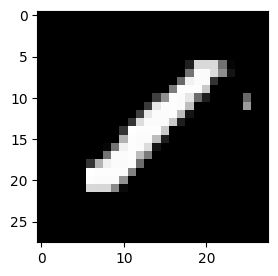

In [33]:
# Visualização dos dados 1
#
from matplotlib import pyplot
from random import randrange
r=randrange(len(train_labels))
print("Imagem de treino nº",r)
print("Label da imagem de treino nº", r, ":", train_labels[r])
fig=plt.figure(figsize=(3, 3))
pyplot.imshow(train_images[r],cmap="gray")

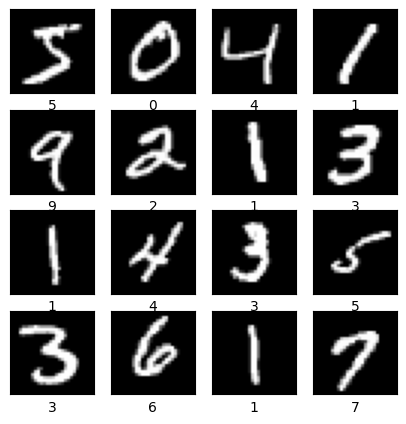

In [34]:
# Visualização dos dados 2
#
from matplotlib import pyplot as plt

plt.figure(figsize=[5,5])
for i in range (16):    # for first 25 images
  plt.subplot(4, 4, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(train_images[i], cmap="gray")
  plt.xlabel(train_labels[i])

plt.show()

In [35]:
# standardização dos inputs: reshape e normalização
#
train_images_resh = train_images.reshape((60000, 28 * 28))
train_inputs = train_images_resh.astype("float32") / 255
val_images_resh = val_images.reshape((10000, 28 * 28))
val_inputs = val_images_resh.astype("float32") / 255

In [36]:
# standardização das labels: one-hot enconding
#
num_classes = 10
num_train_labels = len(train_labels)
num_val_labels = len(val_labels)

train_labels_1hot=np.zeros((num_train_labels,num_classes))
val_labels_1hot=np.zeros((num_val_labels,num_classes))

for i in range(num_train_labels):
  train_labels_1hot[i,train_labels[i]]=1

for i in range(num_val_labels):
  val_labels_1hot[i,val_labels[i]]=1

In [37]:
# Definição duma classe que cria geradores de batches
#
class batchGenerator:
  def __init__(self,inputs,labels,batch_size=128):
    #random_indices = np.random.permutation(inputs.shape[0])
    #inputs_shuffle = inputs[random_indices] # shuffle inputs
    #labels_shuffle = labels[random_indices] # shuffle labels
    self.index = 0
    self.inputs = inputs
    self.labels = labels
    self.batch_size = batch_size
    self.num_batches = np.ceil(len(labels)/batch_size).astype("int")

  def next(self):
    inputs_batch = self.inputs[self.index:self.index+self.batch_size,:]
    labels_batch = self.labels[self.index:self.index+self.batch_size,:]
    self.index += self.batch_size
    return inputs_batch, labels_batch

In [38]:
# testar batchGenerator

batch_generator = batchGenerator(train_inputs,train_labels_1hot,16)
print(batch_generator.num_batches)
model = neuralNet([layer_dense(784,50,relu),layer_dense(50,10,softmax)])

for i in range(batch_generator.num_batches):
  print(i)
  input_batch, labels_batch =  batch_generator.next()
  print(input_batch.shape)
  print(labels_batch[0])
  y,_ = model(input_batch)
  print(y[0])
  if i>2:
    break

3750
0
(16, 784)
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
[0.09994651 0.10007857 0.10009023 0.0999499  0.10003316 0.10008965
 0.10006045 0.09997806 0.09989986 0.09987362]
1
(16, 784)
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
[0.10022176 0.10003371 0.09997478 0.09992043 0.10013668 0.09984745
 0.09992327 0.09999738 0.09991342 0.10003113]
2
(16, 784)
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
[0.10011767 0.10000648 0.10008514 0.09993314 0.10008506 0.09992775
 0.09987493 0.10000805 0.09994328 0.10001851]
3
(16, 784)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
[0.10013413 0.10011674 0.10008827 0.09994749 0.09995962 0.10005548
 0.09989547 0.09998487 0.09988464 0.0999333 ]


### Métricas: Loss e Accuracy

In [39]:
def cross_entropy(model,inputs,labels):
  numExamples = inputs.shape[0]
  batch_generator = batchGenerator(inputs,labels,batch_size=50)
  num_batches = batch_generator.num_batches
  for batch_counter in range(num_batches):
    inputs_batch, labels_batch =  batch_generator.next()
    yout,_ = model(inputs_batch)
    #print(yout.shape)
    cEntropy_batch = - np.sum(labels_batch * np.log(yout), axis=1)
    cEntropy = np.sum(cEntropy_batch,axis=0)/yout.shape[0]
  return cEntropy

In [40]:
cross_entropy(model,train_inputs,train_labels_1hot)

2.302949833539658

In [41]:
def accuracy(model,inputs,labels):
  numExamples = inputs.shape[0]
  numCorrect=0
  batch_generator = batchGenerator(inputs,labels,batch_size=50)
  num_batches = batch_generator.num_batches
  for batch_counter in range(num_batches):
    inputs_batch, labels_batch =  batch_generator.next()
    yout,_ = model(inputs_batch)
    predications = np.argmax(yout,axis=1)
    labels = np.argmax(labels_batch,axis=1)
    numCorrect += np.sum(predications==labels)
  acc = numCorrect/numExamples
  return acc

### Treino

In [42]:
def fit(model,inputs,labels,epochs=5,val_inputs=val_inputs, val_labels=val_labels, batch_size=128):
  history = {"loss" : [],
              "accuracy": [],
              "val_loss":[],
              "val_accuracy": []}
  for epoch_counter in range(epochs):
    batch_generator = batchGenerator(inputs,labels,batch_size)
    num_batches = batch_generator.num_batches
    print("\n")
    print(f"Epoch {epoch_counter+1}:")
    for batch_counter in range(num_batches):
      # treino
      inputs_batch, labels_batch =  batch_generator.next()
      training_step_classification(model,inputs_batch,labels_batch,lr)
      #
      if batch_counter % 10 == 0:
        print("-", end="")
    # metricas
    loss = cross_entropy(model,inputs,labels)
    acc = accuracy(model,inputs,labels)
    val_loss = cross_entropy(model,val_inputs,val_labels)
    val_acc = accuracy(model,val_inputs,val_labels)
    history["loss"] += [loss]
    history["accuracy"] += [acc]
    history["val_loss"] += [val_loss]
    history["val_accuracy"] += [val_acc]
    print(f"\ntrain_loss: {loss:.4f}, \
              train_accuracy: {acc:.4f}, \
              val_loss: {val_loss:.4f}, \
              val_accuracy: {val_acc:.4f}")
  return history


In [43]:
model = neuralNet([layer_dense(784,50,relu),
                   layer_dense(50,10,softmax)])

In [ ]:
lr = .01
history = fit(model,train_inputs,train_labels_1hot,epochs=5,
              val_inputs=val_inputs,val_labels=val_labels_1hot, batch_size=50)



Epoch 1:
------------------------------------------------------------------------------------------------------------------------
train_loss: 0.7793,               train_accuracy: 0.7989,               val_loss: 0.7853,               val_accuracy: 0.8020


Epoch 2:
------------------------------------------------------------------------------------------------------------------------
train_loss: 0.3425,               train_accuracy: 0.8708,               val_loss: 0.5356,               val_accuracy: 0.8761


Epoch 3:
-------------------------------------------------------------------------------------

### Avaliação do modelo

In [ ]:
import matplotlib.pyplot as plt
acc = history["accuracy"]
val_acc = history["val_accuracy"]
loss = history["loss"]
val_loss = history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="val accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="val loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

### Analisar alguns exemplos na performance do modelo

In [ ]:
r=randrange(10000)

print("cheking val image number:", r)
output,_ = model(val_inputs[r])
print("model output is:", output)
prediciton=output.argmax()
print("model prediction is", prediciton)
print("label is", val_labels[r])
pyplot.imshow(val_images[r],cmap="gray")

In [ ]:
# determinar os erros no conjunto de vale
list_errors=[]
for i in range(10000):
  output,_ = model(val_inputs[i])
  pred = output.argmax()
  label = val_labels[i]
  if pred!=label:
    list_errors.append(i)

print(list_errors)
print(len(list_errors))

In [ ]:
# analisar os erros no conjunto de vale
r=randrange(len(list_errors))
error_index = list_errors[r]
print("cheking val image number:", error_index)
output,_ = model(val_inputs[error_index])
print("model output is:", output)
prediciton=output.argmax()
print("model prediction is", prediciton)
print("label is", val_labels[error_index])
pyplot.imshow(val_images[error_index],cmap="gray")

## Aula 6 redes neuroais keras

In [ ]:
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images,test_labels)=mnist.load_data()

In [ ]:
print(train_images.shape)
print(test_images.shape)
print(len(train_labels))
train_labels

In [ ]:
# Para usar no CIFAR10
#
# Para visualização de algumas imagens da base de dados CIFAR10
#
from matplotlib import pyplot as plt
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=[10,10])
for i in range (25):    # for first 25 images
  plt.subplot(5, 5, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(train_images[i], cmap=plt.cm.binary)
  plt.xlabel(class_names[train_labels[i][0]])

plt.show()

In [ ]:
from matplotlib import pyplot
from random import randrange
r=randrange(len(train_labels))
print("Imagem de treino nº",r)
print("Label da imagem de treino nº", r, ":", train_labels[r])
pyplot.imshow(train_images[r],cmap="gray")

In [ ]:
train_images_resh = train_images.reshape((60000, 28 * 28))
train_images_resh = train_images_resh.astype("float32") / 255.0
test_images_resh = test_images.reshape((10000, 28 * 28))
test_images_resh = test_images_resh.astype("float32") / 255.0

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(50,input_shape=(28*28,),activation = "relu"),
    layers.Dense(10,"softmax")
])


model.summary()

In [ ]:
model.compile(optimizer="sgd",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
history=model.fit(train_images_resh, train_labels,
                  validation_data=(test_images_resh,test_labels), epochs=10, batch_size=50)

In [ ]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
predictions=model.predict(test_images_resh)

In [ ]:
r=randrange(10000)

print("cheking test image number:", r)
pred=predictions[r]
print(pred)
pr=predictions[r].argmax()
print("model prediction is", pr)
print("label is", test_labels[r])
pyplot.imshow(test_images[r])

In [ ]:
Errors=[]
for i in range(10000):
  pred=predictions[i].argmax()
  lbl=test_labels[i]
  if pred!=lbl:
    Errors.append(i)

print(Errors)
print(len(Errors))

In [ ]:
s=randrange(len(Errors))
#
r=Errors[s]
print("cheking test image number=", r)
pred=predictions[r]
print(pred)
pr=predictions[r].argmax()
print("model prediction is", pr)
print("label is", test_labels[r])
pyplot.imshow(test_images[r])

## Aula 6 Redes Convolucao Keras cifar10

Redes de convolução:
adaptado de https://www.kaggle.com/code/faressayah/cifar-10-images-classification-using-cnns-88

In [ ]:
from tensorflow.keras.datasets import cifar10
(train_images, train_labels), (val_images,val_labels)=cifar10.load_data()

In [ ]:
from tensorflow.keras.utils import to_categorical
train_images_rsc = train_images / 255.0
val_images_rsc = val_images / 255.0

# Transform target variable into one-hotencoding
train_labels_1h = to_categorical(train_labels)
val_labels_1h = to_categorical(val_labels)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization

INPUT_SHAPE = (32, 32, 3)
KERNEL_SIZE = (3, 3)
model = Sequential()

# Convolution Layer
model.add(Conv2D(filters=32, kernel_size=KERNEL_SIZE, input_shape=INPUT_SHAPE, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=32, kernel_size=KERNEL_SIZE, activation='relu', padding='same'))
model.add(BatchNormalization())
# Pooling layer
model.add(MaxPool2D(pool_size=(2, 2)))
# Dropout layers
model.add(Dropout(0.25))

# more convolution and regularization layers
model.add(Conv2D(filters=64, kernel_size=KERNEL_SIZE,  activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=64, kernel_size=KERNEL_SIZE, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(filters=128, kernel_size=KERNEL_SIZE, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=128, kernel_size=KERNEL_SIZE, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Dense layer
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=["accuracy"])

model.summary()

In [ ]:
history = model.fit(train_images_rsc, train_labels_1h, validation_data=(val_images_rsc,val_labels_1h), epochs=1, batch_size=150)

In [ ]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()